<a href="https://www.kaggle.com/code/wajihsaid/history-of-tunisia?scriptVersionId=296901086" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# ============================================================
# SECTION 0: ENVIRONMENT SETUP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import textwrap
import warnings
import re
import os
from collections import Counter

warnings.filterwarnings('ignore')

# Professional matplotlib configuration
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# Color palette — historically themed
COLORS = {
    'primary': '#8B4513',
    'secondary': '#CD853F',
    'accent': '#2F4F4F',
    'highlight': '#DAA520',
    'danger': '#B22222',
    'cool': '#4682B4',
    'palette': ['#8B4513', '#CD853F', '#2F4F4F', '#DAA520',
                '#B22222', '#4682B4', '#6B8E23', '#708090']
}

print("✓ Environment configured")

✓ Environment configured


In [2]:
# ============================================================
# SECTION 1: DATA LOADING
# ============================================================

INPUT_DIR = '/kaggle/input'

csv_files = []
for root, dirs, files in os.walk(INPUT_DIR):
    for f in files:
        if f.endswith('.csv'):
            csv_files.append(os.path.join(root, f))

if csv_files:
    DATA_PATH = csv_files[0]
    print(f"✓ Found dataset: {DATA_PATH}")
else:
    DATA_PATH = 'historical_events_tunisia_hannibal.csv'
    print(f"ℹ Using local path: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)

print(f"\n{'='*60}")
print(f"  RAW DATA LOADED")
print(f"{'='*60}")
print(f"  Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"  Columns: {list(df_raw.columns)}")
print(f"  Memory: {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB")

✓ Found dataset: /kaggle/input/historical-dataset-tunisia/hannibal.csv

  RAW DATA LOADED
  Shape: 114 rows × 13 columns
  Columns: ['event_id', 'name_of_incident', 'year', 'country', 'place_name', 'type_of_event', 'historical_character', 'description', 'first_person_strategy', 'mistakes_reflection', 'modern_strategy', 'Unnamed: 11', 'Unnamed: 12']
  Memory: 166.5 KB


In [3]:
# ============================================================
# SECTION 2: REMOVE UNNAMED ARTIFACT COLUMNS
# ============================================================
# WHY: CSV files saved with pandas without index=False create
# residual index columns named 'Unnamed: 0', 'Unnamed: 0.1', etc.
# These are pure artifacts — not real data.
# They pollute metadata, waste memory, and would contaminate
# RAG document construction if left in place.

df = df_raw.copy()

print(f"{'='*60}")
print(f"  STEP 1: UNNAMED COLUMN REMOVAL")
print(f"{'='*60}")
print(f"\n  Columns BEFORE: {list(df.columns)}")
print(f"  Column count: {len(df.columns)}")

# Detect all unnamed columns (case-insensitive)
unnamed_cols = [col for col in df.columns
                if col.lower().startswith('unnamed')]

if unnamed_cols:
    print(f"\n  ⚠ Found {len(unnamed_cols)} artifact column(s):")
    for col in unnamed_cols:
        # Show what's inside to confirm it's just an index
        sample_values = df[col].head(5).tolist()
        nunique = df[col].nunique()
        print(f"    • '{col}' — {nunique} unique values, "
              f"sample: {sample_values}")

    # Drop them
    df = df.drop(columns=unnamed_cols)

    print(f"\n  ✓ Removed: {unnamed_cols}")
    print(f"  Columns AFTER: {list(df.columns)}")
    print(f"  Column count: {len(df.columns)}")
else:
    print(f"\n  ✓ No unnamed artifact columns found — data is clean")

# Update df_raw to match (for consistent audit comparisons later)
df_raw = df_raw.drop(columns=unnamed_cols, errors='ignore')

print(f"\n  Final schema:")
for i, col in enumerate(df.columns, 1):
    print(f"    {i:2d}. {col}")

  STEP 1: UNNAMED COLUMN REMOVAL

  Columns BEFORE: ['event_id', 'name_of_incident', 'year', 'country', 'place_name', 'type_of_event', 'historical_character', 'description', 'first_person_strategy', 'mistakes_reflection', 'modern_strategy', 'Unnamed: 11', 'Unnamed: 12']
  Column count: 13

  ⚠ Found 2 artifact column(s):
    • 'Unnamed: 11' — 1 unique values, sample: [nan, nan, nan, nan, nan]
    • 'Unnamed: 12' — 1 unique values, sample: [nan, nan, nan, nan, nan]

  ✓ Removed: ['Unnamed: 11', 'Unnamed: 12']
  Columns AFTER: ['event_id', 'name_of_incident', 'year', 'country', 'place_name', 'type_of_event', 'historical_character', 'description', 'first_person_strategy', 'mistakes_reflection', 'modern_strategy']
  Column count: 11

  Final schema:
     1. event_id
     2. name_of_incident
     3. year
     4. country
     5. place_name
     6. type_of_event
     7. historical_character
     8. description
     9. first_person_strategy
    10. mistakes_reflection
    11. modern_strategy


In [4]:
# ============================================================
# SECTION 3: COMPREHENSIVE DATA AUDIT
# ============================================================
# WHY: You cannot clean what you do not understand.
# This audit creates a baseline for all subsequent cleaning.

print(f"\n{'='*70}")
print(f"  DATA AUDIT REPORT")
print(f"{'='*70}")

# --- 3.1 Schema Validation ---
print(f"\n{'─'*50}")
print(f"  1. SCHEMA VALIDATION")
print(f"{'─'*50}")

EXPECTED_COLUMNS = [
    'event_id', 'name_of_incident', 'year', 'country',
    'place_name', 'type_of_event', 'historical_character',
    'description', 'first_person_strategy', 'mistakes_reflection',
    'modern_strategy'
]

actual_cols = list(df.columns)
missing_cols = [c for c in EXPECTED_COLUMNS if c not in actual_cols]
extra_cols = [c for c in actual_cols if c not in EXPECTED_COLUMNS]

print(f"  Expected: {len(EXPECTED_COLUMNS)} columns")
print(f"  Actual:   {len(actual_cols)} columns")
if missing_cols:
    print(f"  ⚠ MISSING: {missing_cols}")
if extra_cols:
    print(f"  ℹ EXTRA:   {extra_cols}")
if not missing_cols and not extra_cols:
    print(f"  ✓ Schema matches perfectly")

# --- 3.2 Data Types ---
print(f"\n{'─'*50}")
print(f"  2. DATA TYPES")
print(f"{'─'*50}")
for col in df.columns:
    dtype = df[col].dtype
    nunique = df[col].nunique()
    print(f"  {col:30s} | {str(dtype):10s} | {nunique:4d} unique")

# --- 3.3 Missing Values ---
print(f"\n{'─'*50}")
print(f"  3. MISSING VALUES")
print(f"{'─'*50}")

narrative_cols = ['description', 'first_person_strategy',
                  'mistakes_reflection', 'modern_strategy']
metadata_cols = ['event_id', 'name_of_incident', 'year',
                 'country', 'place_name', 'type_of_event',
                 'historical_character']

for col in df.columns:
    total = len(df)
    null_count = df[col].isna().sum()
    pct = (null_count / total) * 100

    # Check semantic nulls
    semantic_nulls = 0
    if df[col].dtype == 'object':
        semantic_nulls = df[col].apply(
            lambda x: isinstance(x, str) and x.strip().lower() in
            ['', 'n/a', 'na', 'none', 'unknown', 'not available',
             'not applicable', '-', '--', 'null', 'nan']
        ).sum()

    role = "NARRATIVE" if col in narrative_cols else "METADATA"
    status = "✓" if null_count == 0 and semantic_nulls == 0 else "⚠"

    print(f"  {status} {col:30s} | {role:9s} | "
          f"null: {null_count:3d} ({pct:5.1f}%) | "
          f"semantic null: {semantic_nulls:3d}")

# --- 3.4 Duplicates ---
print(f"\n{'─'*50}")
print(f"  4. DUPLICATES")
print(f"{'─'*50}")

exact_dupes = df.duplicated().sum()
print(f"  Exact row duplicates: {exact_dupes}")

if 'event_id' in df.columns:
    id_dupes = df['event_id'].duplicated().sum()
    print(f"  Duplicate event_ids: {id_dupes}")

if 'description' in df.columns:
    desc_dupes = df['description'].dropna().duplicated().sum()
    print(f"  Duplicate descriptions: {desc_dupes}")

# --- 3.5 Text Quality ---
print(f"\n{'─'*50}")
print(f"  5. TEXT QUALITY")
print(f"{'─'*50}")

for col in narrative_cols:
    if col in df.columns:
        text_data = df[col].dropna()
        if len(text_data) > 0:
            word_counts = text_data.apply(lambda x: len(str(x).split()))
            short = (word_counts < 20).sum()
            print(f"\n  {col}:")
            print(f"    Words — min: {word_counts.min()} | "
                  f"median: {word_counts.median():.0f} | "
                  f"max: {word_counts.max()} | mean: {word_counts.mean():.1f}")
            if short > 0:
                print(f"    ⚠ {short} entries below 20 words")

# --- 3.6 Entity Consistency ---
print(f"\n{'─'*50}")
print(f"  6. ENTITY CONSISTENCY")
print(f"{'─'*50}")

entity_cols = ['country', 'place_name', 'historical_character', 'type_of_event']
for col in entity_cols:
    if col in df.columns:
        unique_vals = df[col].dropna().unique()
        print(f"\n  {col} ({len(unique_vals)} unique):")
        for v in sorted(unique_vals):
            count = (df[col] == v).sum()
            print(f"    • '{v}' — {count}")

print(f"\n{'='*70}")
print(f"  END OF AUDIT")
print(f"{'='*70}")


  DATA AUDIT REPORT

──────────────────────────────────────────────────
  1. SCHEMA VALIDATION
──────────────────────────────────────────────────
  Expected: 11 columns
  Actual:   11 columns
  ✓ Schema matches perfectly

──────────────────────────────────────────────────
  2. DATA TYPES
──────────────────────────────────────────────────
  event_id                       | object     |  114 unique
  name_of_incident               | object     |  114 unique
  year                           | int64      |   86 unique
  country                        | object     |    1 unique
  place_name                     | object     |   48 unique
  type_of_event                  | object     |    7 unique
  historical_character           | object     |   78 unique
  description                    | object     |  114 unique
  first_person_strategy          | object     |  114 unique
  mistakes_reflection            | object     |  114 unique
  modern_strategy                | object     |  114 unique

In [5]:
# ============================================================
# SECTION 4: DATA CLEANING
# ============================================================

print(f"\n{'='*70}")
print(f"  DATA CLEANING PIPELINE")
print(f"{'='*70}")

# --- 4.1 Column Name Standardization ---
print(f"\n{'─'*50}")
print(f"  4.1 COLUMN NAME STANDARDIZATION")
print(f"{'─'*50}")

rename_map = {}
for col in df.columns:
    new_name = col.strip().lower()
    new_name = re.sub(r'[^a-z0-9]+', '_', new_name)
    new_name = new_name.strip('_')
    rename_map[col] = new_name

df = df.rename(columns=rename_map)

changed = {k: v for k, v in rename_map.items() if k != v}
if changed:
    for old, new in changed.items():
        print(f"  '{old}' → '{new}'")
else:
    print("  ✓ Already standardized")


  DATA CLEANING PIPELINE

──────────────────────────────────────────────────
  4.1 COLUMN NAME STANDARDIZATION
──────────────────────────────────────────────────
  ✓ Already standardized


In [6]:
# --- 4.2 Semantic Null Conversion ---
print(f"\n{'─'*50}")
print(f"  4.2 SEMANTIC NULL CONVERSION")
print(f"{'─'*50}")
# WHY: Strings like "N/A", "None", "" look present to pandas
# but carry zero information. If embedded, they produce
# meaningless vectors that pollute retrieval.

null_patterns = ['', 'n/a', 'na', 'none', 'unknown',
                 'not available', 'not applicable',
                 '-', '--', 'null', 'nan', 'n.a.', 'n.a']

total_converted = 0
for col in df.select_dtypes(include='object').columns:
    mask = df[col].apply(
        lambda x: isinstance(x, str) and x.strip().lower() in null_patterns
    )
    count = mask.sum()
    if count > 0:
        df.loc[mask, col] = np.nan
        total_converted += count
        print(f"  {col}: {count} semantic nulls → NaN")

if total_converted == 0:
    print("  ✓ No semantic nulls found")
else:
    print(f"  Total converted: {total_converted}")


──────────────────────────────────────────────────
  4.2 SEMANTIC NULL CONVERSION
──────────────────────────────────────────────────
  ✓ No semantic nulls found


In [7]:
# --- 4.3 Whitespace Normalization ---
print(f"\n{'─'*50}")
print(f"  4.3 WHITESPACE NORMALIZATION")
print(f"{'─'*50}")
# WHY: "The  Battle   of  Zama" and "The Battle of Zama"
# embed differently. Normalize whitespace for clean embeddings.

narrative_cols = ['description', 'first_person_strategy',
                  'mistakes_reflection', 'modern_strategy']

for col in df.select_dtypes(include='object').columns:
    if col in narrative_cols:
        # Preserve paragraph breaks in narratives
        df[col] = df[col].apply(
            lambda x: re.sub(r'[ \t]+', ' ',
                       re.sub(r'\n\s*\n', '\n\n',
                       str(x))).strip()
            if pd.notna(x) else x
        )
    else:
        # Aggressive cleanup for metadata
        df[col] = df[col].apply(
            lambda x: ' '.join(str(x).split()) if pd.notna(x) else x
        )

print("  ✓ Whitespace normalized (paragraphs preserved in narratives)")


──────────────────────────────────────────────────
  4.3 WHITESPACE NORMALIZATION
──────────────────────────────────────────────────
  ✓ Whitespace normalized (paragraphs preserved in narratives)


In [8]:
# --- 4.4 Entity Normalization ---
print(f"\n{'─'*50}")
print(f"  4.4 ENTITY NORMALIZATION")
print(f"{'─'*50}")
# WHY CRITICAL FOR RAG:
# Query "What did Hannibal do?" must match documents containing
# "Hannibal Barca", "hannibal", "HANNIBAL" equally.
# Inconsistent entities fragment the vector space.

# Historical Character
if 'historical_character' in df.columns:
    df['historical_character'] = (
        df['historical_character']
        .apply(lambda x: x.strip().title() if pd.notna(x) else x)
    )

    character_map = {
        'Hannibal': 'Hannibal Barca',
        'Hannibal Barca': 'Hannibal Barca',
        'Hamilcar': 'Hamilcar Barca',
        'Hamilcar Barca': 'Hamilcar Barca',
        'Scipio': 'Scipio Africanus',
        'Scipio Africanus': 'Scipio Africanus',
        'Publius Cornelius Scipio': 'Scipio Africanus',
    }

    before = df['historical_character'].copy()
    df['historical_character'] = (
        df['historical_character'].map(character_map)
        .fillna(df['historical_character'])
    )
    n_changed = (before != df['historical_character']).sum()
    print(f"  historical_character: {n_changed} values normalized")

# Country
if 'country' in df.columns:
    df['country'] = (
        df['country']
        .apply(lambda x: x.strip().title() if pd.notna(x) else x)
    )

    country_map = {
        'Tunisia': 'Tunisia',
        'Italy': 'Italy',
        'Spain': 'Spain',
        'Hispania': 'Spain (Hispania)',
        'Gaul': 'Gaul (France)',
    }
    df['country'] = (
        df['country'].map(country_map)
        .fillna(df['country'])
    )
    print(f"  country: normalized → {sorted(df['country'].dropna().unique())}")

# Place Name
if 'place_name' in df.columns:
    df['place_name'] = (
        df['place_name']
        .apply(lambda x: x.strip().title() if pd.notna(x) else x)
    )

    place_map = {
        'Zama': 'Zama',
        'Cannae': 'Cannae',
        'Carthage': 'Carthage',
        'Lake Trasimene': 'Lake Trasimene',
        'Trasimene': 'Lake Trasimene',
        'Lake Trasimenus': 'Lake Trasimene',
        'Trebia': 'Trebia',
        'River Trebia': 'Trebia',
        'Saguntum': 'Saguntum',
        'Sagunto': 'Saguntum',
    }
    df['place_name'] = (
        df['place_name'].map(place_map)
        .fillna(df['place_name'])
    )
    print(f"  place_name: normalized → {sorted(df['place_name'].dropna().unique())}")

# Type of Event
if 'type_of_event' in df.columns:
    df['type_of_event'] = (
        df['type_of_event']
        .apply(lambda x: x.strip().title() if pd.notna(x) else x)
    )

    event_type_map = {
        'Battle': 'Battle',
        'War': 'War',
        'Siege': 'Siege',
        'Diplomacy': 'Diplomacy',
        'Diplomatic': 'Diplomacy',
        'Treaty': 'Treaty',
        'March': 'Military Campaign',
        'Campaign': 'Military Campaign',
        'Military Campaign': 'Military Campaign',
        'Strategic': 'Strategy',
        'Strategy': 'Strategy',
    }
    df['type_of_event'] = (
        df['type_of_event'].map(event_type_map)
        .fillna(df['type_of_event'])
    )
    print(f"  type_of_event: normalized → {sorted(df['type_of_event'].dropna().unique())}")


──────────────────────────────────────────────────
  4.4 ENTITY NORMALIZATION
──────────────────────────────────────────────────
  historical_character: 0 values normalized
  country: normalized → ['Tunisia']
  place_name: normalized → ['Aegates Islands', 'Alps Mountains', 'Bardo Museum', 'Bardo Palace', 'Bithynia', 'Bizerte', 'Cannae, Apulia', 'Cap Bon', 'Carthage', 'Carthage Harbor', 'Carthage Senate', 'Carthaginian Borderlands', 'Carthago Nova', 'Cirta', 'Coastal Tunisia', 'Djerba', 'France', 'Gafsa', 'Hammamet', 'Kairouan', 'Ksar Hellal', 'Lake Trasimene', 'Libya', 'Mahdia', 'Mateur', 'Monastir', 'Nabeul', 'Numidia', 'Paris', 'Raqqada', 'Saguntum', 'Sahara', 'Sahel Region', 'Sfax', 'Sicily', 'Sidi Bou Said', 'Sidi Bouzid', 'Southern Tunisia', 'Tabarka', 'Tataouine', 'Tozeur', 'Trebia River', 'Tunis', 'Tunisia', 'Tunisian Plains', 'West African Coast', 'Zama', 'Zama, North Africa']
  type_of_event: normalized → ['Battle', 'Cultural Reform', 'Diplomatic Negotiation', 'Military Campa

In [9]:
# --- 4.5 Missing Value Handling ---
print(f"\n{'─'*50}")
print(f"  4.5 MISSING VALUE HANDLING")
print(f"{'─'*50}")
# STRATEGY:
# Metadata → 'Unknown' (so metadata filters don't break)
# Narrative → flag/keep empty (DO NOT fabricate historical content)
# Year → keep NaN (numeric integrity)

# Metadata text columns
metadata_text_cols = ['country', 'place_name', 'type_of_event',
                      'historical_character', 'name_of_incident']

for col in metadata_text_cols:
    if col in df.columns:
        n_miss = df[col].isna().sum()
        if n_miss > 0:
            df[col] = df[col].fillna('Unknown')
            print(f"  {col}: {n_miss} NaN → 'Unknown'")
        else:
            print(f"  {col}: complete ✓")

# Year
if 'year' in df.columns:
    n_miss = df['year'].isna().sum()
    if n_miss > 0:
        df['year_missing'] = df['year'].isna().astype(int)
        print(f"  year: {n_miss} NaN → kept as NaN, flag created")
    else:
        print(f"  year: complete ✓")

# Narrative columns
narrative_importance = {
    'description': 'critical',
    'first_person_strategy': 'important',
    'mistakes_reflection': 'optional',
    'modern_strategy': 'optional'
}

for col, importance in narrative_importance.items():
    if col in df.columns:
        n_miss = df[col].isna().sum()
        if n_miss > 0:
            if importance == 'critical':
                df['description_missing'] = df[col].isna().astype(int)
                print(f"  {col}: {n_miss} NaN → ⚠ FLAGGED (critical for RAG)")
            else:
                df[col] = df[col].fillna('')
                print(f"  {col}: {n_miss} NaN → empty string ({importance})")
        else:
            print(f"  {col}: complete ✓")

print(f"\n  Remaining NaN total: {df.isna().sum().sum()}")


──────────────────────────────────────────────────
  4.5 MISSING VALUE HANDLING
──────────────────────────────────────────────────
  country: complete ✓
  place_name: complete ✓
  type_of_event: complete ✓
  historical_character: complete ✓
  name_of_incident: complete ✓
  year: complete ✓
  description: complete ✓
  first_person_strategy: complete ✓
  mistakes_reflection: complete ✓
  modern_strategy: complete ✓

  Remaining NaN total: 0


In [10]:
# --- 4.6 Duplicate Handling ---
print(f"\n{'─'*50}")
print(f"  4.6 DUPLICATE HANDLING")
print(f"{'─'*50}")
# WHY: Duplicates waste top-k retrieval slots in RAG
# with repeated information, reducing answer diversity.

initial_count = len(df)

# Exact duplicates
exact_dupes = df.duplicated().sum()
if exact_dupes > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"  Removed {exact_dupes} exact duplicate rows")
else:
    print(f"  ✓ No exact duplicates")

# Duplicate event_ids
if 'event_id' in df.columns:
    id_dupes = df['event_id'].duplicated(keep=False).sum()
    if id_dupes > 0:
        print(f"  ⚠ {id_dupes} rows share duplicate event_ids")

        def keep_most_complete(group):
            if len(group) == 1:
                return group
            completeness = group.notna().sum(axis=1)
            return group.loc[[completeness.idxmax()]]

        df = (df.groupby('event_id', group_keys=False)
              .apply(keep_most_complete)
              .reset_index(drop=True))
        print(f"  → Kept most complete row per event_id")
    else:
        print(f"  ✓ All event_ids unique")

# Duplicate descriptions
if 'description' in df.columns:
    desc_dupes = df['description'].dropna().duplicated().sum()
    if desc_dupes > 0:
        df['is_duplicate_description'] = (
            df['description'].duplicated(keep='first').astype(int)
        )
        print(f"  ⚠ {desc_dupes} duplicate descriptions flagged")
    else:
        print(f"  ✓ All descriptions unique")

print(f"\n  Rows: {initial_count} → {len(df)} "
      f"(removed {initial_count - len(df)})")


──────────────────────────────────────────────────
  4.6 DUPLICATE HANDLING
──────────────────────────────────────────────────
  ✓ No exact duplicates
  ✓ All event_ids unique
  ✓ All descriptions unique

  Rows: 114 → 114 (removed 0)


In [11]:
# --- 4.7 Data Type Enforcement ---
print(f"\n{'─'*50}")
print(f"  4.7 DATA TYPE ENFORCEMENT")
print(f"{'─'*50}")
# WHY: Vector DB metadata filters need correct types.
# year must be numeric for range queries ("events before 200 BCE")

if 'year' in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    print(f"  year → Int64 (nullable integer for BCE dates)")

if 'event_id' in df.columns:
    df['event_id'] = df['event_id'].astype(str)
    print(f"  event_id → string (identifier)")

for col in ['country', 'type_of_event', 'historical_character']:
    if col in df.columns:
        df[col] = df[col].astype('category')
        print(f"  {col} → category ({df[col].nunique()} levels)")


──────────────────────────────────────────────────
  4.7 DATA TYPE ENFORCEMENT
──────────────────────────────────────────────────
  year → Int64 (nullable integer for BCE dates)
  event_id → string (identifier)
  country → category (1 levels)
  type_of_event → category (7 levels)
  historical_character → category (78 levels)


In [12]:
# --- 4.8 Text Quality Validation ---
print(f"\n{'─'*50}")
print(f"  4.8 TEXT QUALITY VALIDATION")
print(f"{'─'*50}")
# WHY: Quality gate — only records with sufficient text
# should enter the vector store.

MIN_WORDS_FOR_RAG = 15

for col in narrative_cols:
    if col in df.columns:
        word_counts = df[col].apply(
            lambda x: len(str(x).split())
            if pd.notna(x) and str(x).strip() else 0
        )

        flag_col = f'{col}_quality'
        df[flag_col] = 'good'
        df.loc[(word_counts < MIN_WORDS_FOR_RAG) & (word_counts > 0), flag_col] = 'short'
        df.loc[word_counts == 0, flag_col] = 'empty'

        n_good = (df[flag_col] == 'good').sum()
        n_short = (df[flag_col] == 'short').sum()
        n_empty = (df[flag_col] == 'empty').sum()

        print(f"  {col}: ✓ good={n_good}  ⚠ short={n_short}  ✗ empty={n_empty}")

# RAG readiness flag
if 'description' in df.columns:
    df['rag_ready'] = df['description'].apply(
        lambda x: 1 if pd.notna(x) and len(str(x).split()) >= MIN_WORDS_FOR_RAG else 0
    )
    n_ready = df['rag_ready'].sum()
    print(f"\n  RAG readiness: {n_ready}/{len(df)} "
          f"({100*n_ready/len(df):.1f}%) records ready for embedding")

print(f"\n{'='*70}")
print(f"  ✓ CLEANING COMPLETE")
print(f"{'='*70}")
print(f"  Rows: {len(df)} | Columns: {len(df.columns)}")


──────────────────────────────────────────────────
  4.8 TEXT QUALITY VALIDATION
──────────────────────────────────────────────────
  description: ✓ good=114  ⚠ short=0  ✗ empty=0
  first_person_strategy: ✓ good=114  ⚠ short=0  ✗ empty=0
  mistakes_reflection: ✓ good=114  ⚠ short=0  ✗ empty=0
  modern_strategy: ✓ good=113  ⚠ short=1  ✗ empty=0

  RAG readiness: 114/114 (100.0%) records ready for embedding

  ✓ CLEANING COMPLETE
  Rows: 114 | Columns: 16


In [13]:
# ============================================================
# SECTION 5: FEATURE ENGINEERING
# ============================================================

print(f"\n{'='*70}")
print(f"  FEATURE ENGINEERING")
print(f"{'='*70}")

# ─── 5.1 TEMPORAL FEATURES ───
print(f"\n  5.1 Temporal Features")
print(f"  {'─'*40}")

if 'year' in df.columns:
    # Era classification for RAG metadata filtering
    def classify_era(year):
        if pd.isna(year):
            return 'Unknown'
        year = int(year)
        if year <= -300:
            return '4th Century BCE & Earlier'
        elif year <= -200:
            return '3rd Century BCE'
        elif year <= -100:
            return '2nd Century BCE'
        elif year <= 0:
            return '1st Century BCE'
        else:
            return 'CE'

    df['era'] = df['year'].apply(classify_era)
    print(f"    era: {df['era'].value_counts().to_dict()}")

    # Human-readable year display
    df['year_display'] = df['year'].apply(
        lambda y: f"{abs(int(y))} BCE" if pd.notna(y) and int(y) < 0
        else (f"{int(y)} CE" if pd.notna(y) else "Unknown")
    )
    print(f"    year_display ✓")

    # Chronological rank
    df['chrono_rank'] = df['year'].rank(
        method='dense', na_option='bottom'
    ).astype('Int64')
    print(f"    chrono_rank ✓")

# ─── 5.2 TEXTUAL FEATURES ───
print(f"\n  5.2 Textual Features")
print(f"  {'─'*40}")

for col in narrative_cols:
    if col in df.columns:
        wc_col = f'{col}_word_count'
        cc_col = f'{col}_char_count'

        df[wc_col] = df[col].apply(
            lambda x: len(str(x).split())
            if pd.notna(x) and str(x).strip() else 0
        )
        df[cc_col] = df[col].apply(
            lambda x: len(str(x))
            if pd.notna(x) and str(x).strip() else 0
        )
        print(f"    {wc_col}: mean={df[wc_col].mean():.1f}")

# Total narrative richness
wc_cols = [f'{c}_word_count' for c in narrative_cols
           if f'{c}_word_count' in df.columns]
if wc_cols:
    df['total_narrative_words'] = df[wc_cols].sum(axis=1)
    print(f"    total_narrative_words: mean={df['total_narrative_words'].mean():.0f}")

# Narrative completeness
filled = sum(
    df[col].apply(
        lambda x: 1 if pd.notna(x) and str(x).strip()
        and len(str(x).split()) > 5 else 0
    ) for col in narrative_cols if col in df.columns
)
n_narrative = len([c for c in narrative_cols if c in df.columns])
df['narrative_completeness'] = filled
df['narrative_completeness_pct'] = (filled / n_narrative * 100).round(1)
print(f"    Fully complete records: "
      f"{(df['narrative_completeness_pct'] == 100).sum()}/{len(df)}")

# ─── 5.3 RAG COMPOSITE DOCUMENT ───
print(f"\n  5.3 RAG Composite Document")
print(f"  {'─'*40}")

def build_rag_document(row):
    """Build unified text for vector embedding."""
    parts = []

    # Metadata header
    header = []
    if pd.notna(row.get('name_of_incident')) and str(row.get('name_of_incident')) != 'Unknown':
        header.append(f"Event: {row['name_of_incident']}")
    if pd.notna(row.get('year')):
        header.append(f"Year: {row.get('year_display', row['year'])}")
    if pd.notna(row.get('place_name')) and str(row.get('place_name')) != 'Unknown':
        header.append(f"Location: {row['place_name']}")
    if pd.notna(row.get('country')):
        country_val = str(row['country'])
        if country_val != 'Unknown':
            header.append(f"Country: {country_val}")
    if pd.notna(row.get('type_of_event')):
        header.append(f"Type: {str(row['type_of_event'])}")
    if pd.notna(row.get('historical_character')):
        header.append(f"Historical Figure: {str(row['historical_character'])}")

    if header:
        parts.append(" | ".join(header))

    # Narrative sections
    section_map = {
        'description': 'Description',
        'first_person_strategy': 'First-Person Account',
        'mistakes_reflection': 'Reflection on Mistakes',
        'modern_strategy': 'Modern Strategic Analysis'
    }

    for col, label in section_map.items():
        val = row.get(col, '')
        if pd.notna(val) and str(val).strip():
            parts.append(f"{label}: {val}")

    return "\n\n".join(parts)

df['rag_document'] = df.apply(build_rag_document, axis=1)
df['rag_document_word_count'] = df['rag_document'].apply(lambda x: len(x.split()))

print(f"    ✓ rag_document created")
print(f"    Word count — min: {df['rag_document_word_count'].min()}, "
      f"median: {df['rag_document_word_count'].median():.0f}, "
      f"max: {df['rag_document_word_count'].max()}")

# ─── 5.4 ANALYSIS FEATURES ───
print(f"\n  5.4 Analysis Features")
print(f"  {'─'*40}")

if 'first_person_strategy' in df.columns:
    df['first_person_question_count'] = df['first_person_strategy'].apply(
        lambda x: str(x).count('?') if pd.notna(x) else 0
    )
    df['first_person_exclamation_count'] = df['first_person_strategy'].apply(
        lambda x: str(x).count('!') if pd.notna(x) else 0
    )
    print(f"    question_count: mean={df['first_person_question_count'].mean():.2f}")
    print(f"    exclamation_count: mean={df['first_person_exclamation_count'].mean():.2f}")

print(f"\n  Total columns: {len(df.columns)}")
print(f"  Engineered features: {len(df.columns) - len(EXPECTED_COLUMNS)}")


  FEATURE ENGINEERING

  5.1 Temporal Features
  ────────────────────────────────────────
    era: {'CE': 87, '3rd Century BCE': 18, '4th Century BCE & Earlier': 6, '2nd Century BCE': 3}
    year_display ✓
    chrono_rank ✓

  5.2 Textual Features
  ────────────────────────────────────────
    description_word_count: mean=30.4
    first_person_strategy_word_count: mean=30.7
    mistakes_reflection_word_count: mean=31.3
    modern_strategy_word_count: mean=29.5
    total_narrative_words: mean=122
    Fully complete records: 113/114

  5.3 RAG Composite Document
  ────────────────────────────────────────
    ✓ rag_document created
    Word count — min: 129, median: 150, max: 209

  5.4 Analysis Features
  ────────────────────────────────────────
    question_count: mean=0.04
    exclamation_count: mean=0.00

  Total columns: 34
  Engineered features: 23


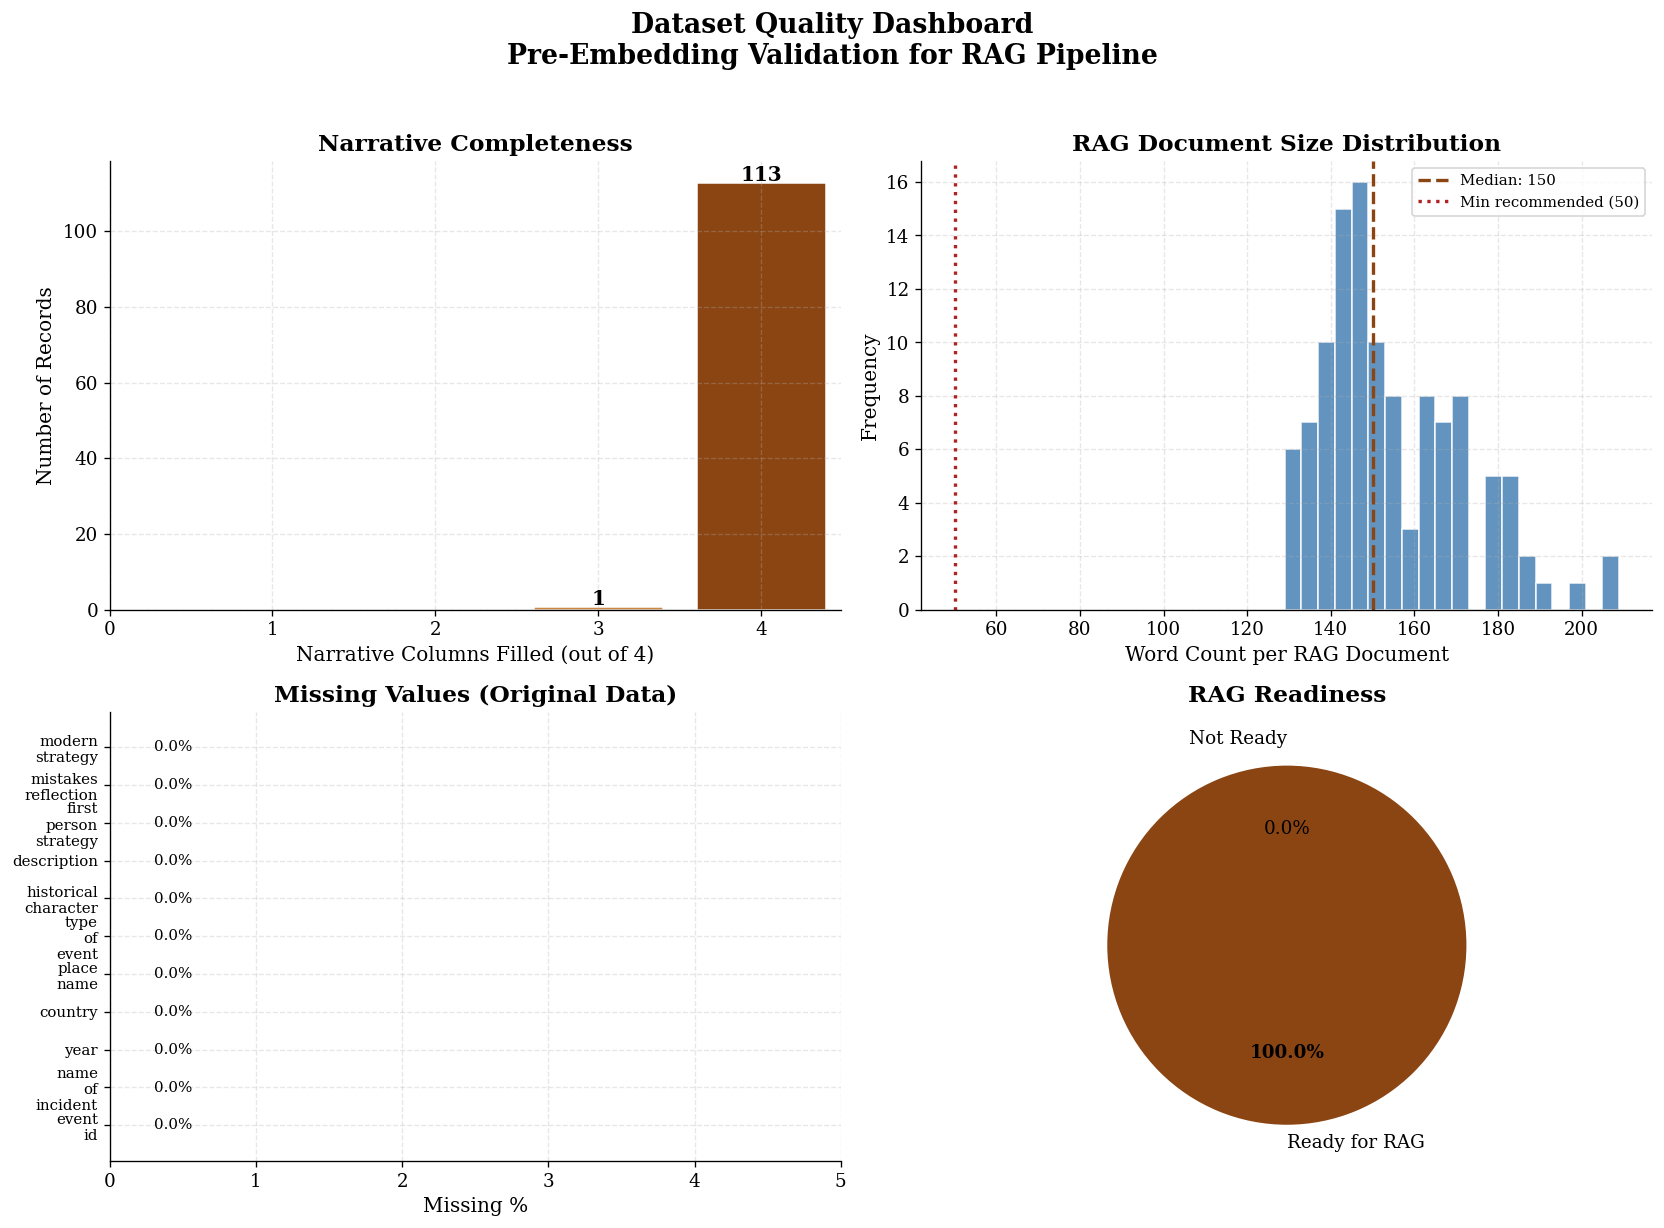

📊 Panel 1: Records with 4/4 narratives provide richest AI character responses
📊 Panel 2: Documents should be 50-500 words for optimal embedding quality
📊 Panel 3: Original data baseline — validates our cleaning effort
📊 Panel 4: Only 'Ready' records should enter the vector store


In [14]:
# ============================================================
# SECTION 6: VISUALIZATIONS
# ============================================================

# --- 6.1 Dataset Quality Dashboard ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dataset Quality Dashboard\n'
             'Pre-Embedding Validation for RAG Pipeline',
             fontsize=16, fontweight='bold', y=1.02)

# Panel 1: Narrative Completeness
ax1 = axes[0, 0]
if 'narrative_completeness' in df.columns:
    comp_counts = df['narrative_completeness'].value_counts().sort_index()
    max_n = df['narrative_completeness'].max()

    bar_colors = [COLORS['danger'] if x < max_n/2
                  else COLORS['secondary'] if x < max_n
                  else COLORS['primary'] for x in comp_counts.index]

    bars = ax1.bar(comp_counts.index, comp_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, comp_counts.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Narrative Columns Filled (out of 4)')
    ax1.set_ylabel('Number of Records')
    ax1.set_title('Narrative Completeness')
    ax1.set_xticks(range(max_n + 1))

# Panel 2: RAG Document Word Count Distribution
ax2 = axes[0, 1]
if 'rag_document_word_count' in df.columns:
    wc = df['rag_document_word_count']
    ax2.hist(wc, bins=min(20, len(wc)//2 + 1),
             color=COLORS['cool'], edgecolor='white', alpha=0.85)
    ax2.axvline(wc.median(), color=COLORS['primary'],
               linestyle='--', linewidth=2, label=f'Median: {wc.median():.0f}')
    ax2.axvline(50, color=COLORS['danger'],
               linestyle=':', linewidth=2, label='Min recommended (50)')
    ax2.set_xlabel('Word Count per RAG Document')
    ax2.set_ylabel('Frequency')
    ax2.set_title('RAG Document Size Distribution')
    ax2.legend(fontsize=9)

# Panel 3: Missing Values (original data)
ax3 = axes[1, 0]
available_cols = [c for c in EXPECTED_COLUMNS if c in df_raw.columns]
missing_pct = (df_raw[available_cols].isna().sum() / len(df_raw) * 100)
bar_colors_missing = [COLORS['primary'] if v == 0
                      else COLORS['secondary'] if v < 10
                      else COLORS['danger'] for v in missing_pct.values]

ax3.barh(range(len(available_cols)), missing_pct.values,
         color=bar_colors_missing, edgecolor='white', linewidth=1)
ax3.set_yticks(range(len(available_cols)))
ax3.set_yticklabels([c.replace('_', '\n') for c in available_cols], fontsize=9)
ax3.set_xlabel('Missing %')
ax3.set_title('Missing Values (Original Data)')
ax3.set_xlim(0, max(missing_pct.values.max() * 1.3, 5))
for i, v in enumerate(missing_pct.values):
    ax3.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# Panel 4: RAG Readiness
ax4 = axes[1, 1]
if 'rag_ready' in df.columns:
    ready_counts = df['rag_ready'].value_counts()
    sizes = [ready_counts.get(1, 0), ready_counts.get(0, 0)]
    labels = ['Ready for RAG', 'Not Ready']
    colors_pie = [COLORS['primary'], COLORS['danger']]
    wedges, texts, autotexts = ax4.pie(
        sizes, labels=labels, colors=colors_pie,
        autopct='%1.1f%%', explode=(0.05, 0),
        startangle=90, textprops={'fontsize': 11}
    )
    autotexts[0].set_fontweight('bold')
    ax4.set_title('RAG Readiness')

plt.tight_layout()
plt.savefig('01_quality_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Panel 1: Records with 4/4 narratives provide richest AI character responses")
print("📊 Panel 2: Documents should be 50-500 words for optimal embedding quality")
print("📊 Panel 3: Original data baseline — validates our cleaning effort")
print("📊 Panel 4: Only 'Ready' records should enter the vector store")

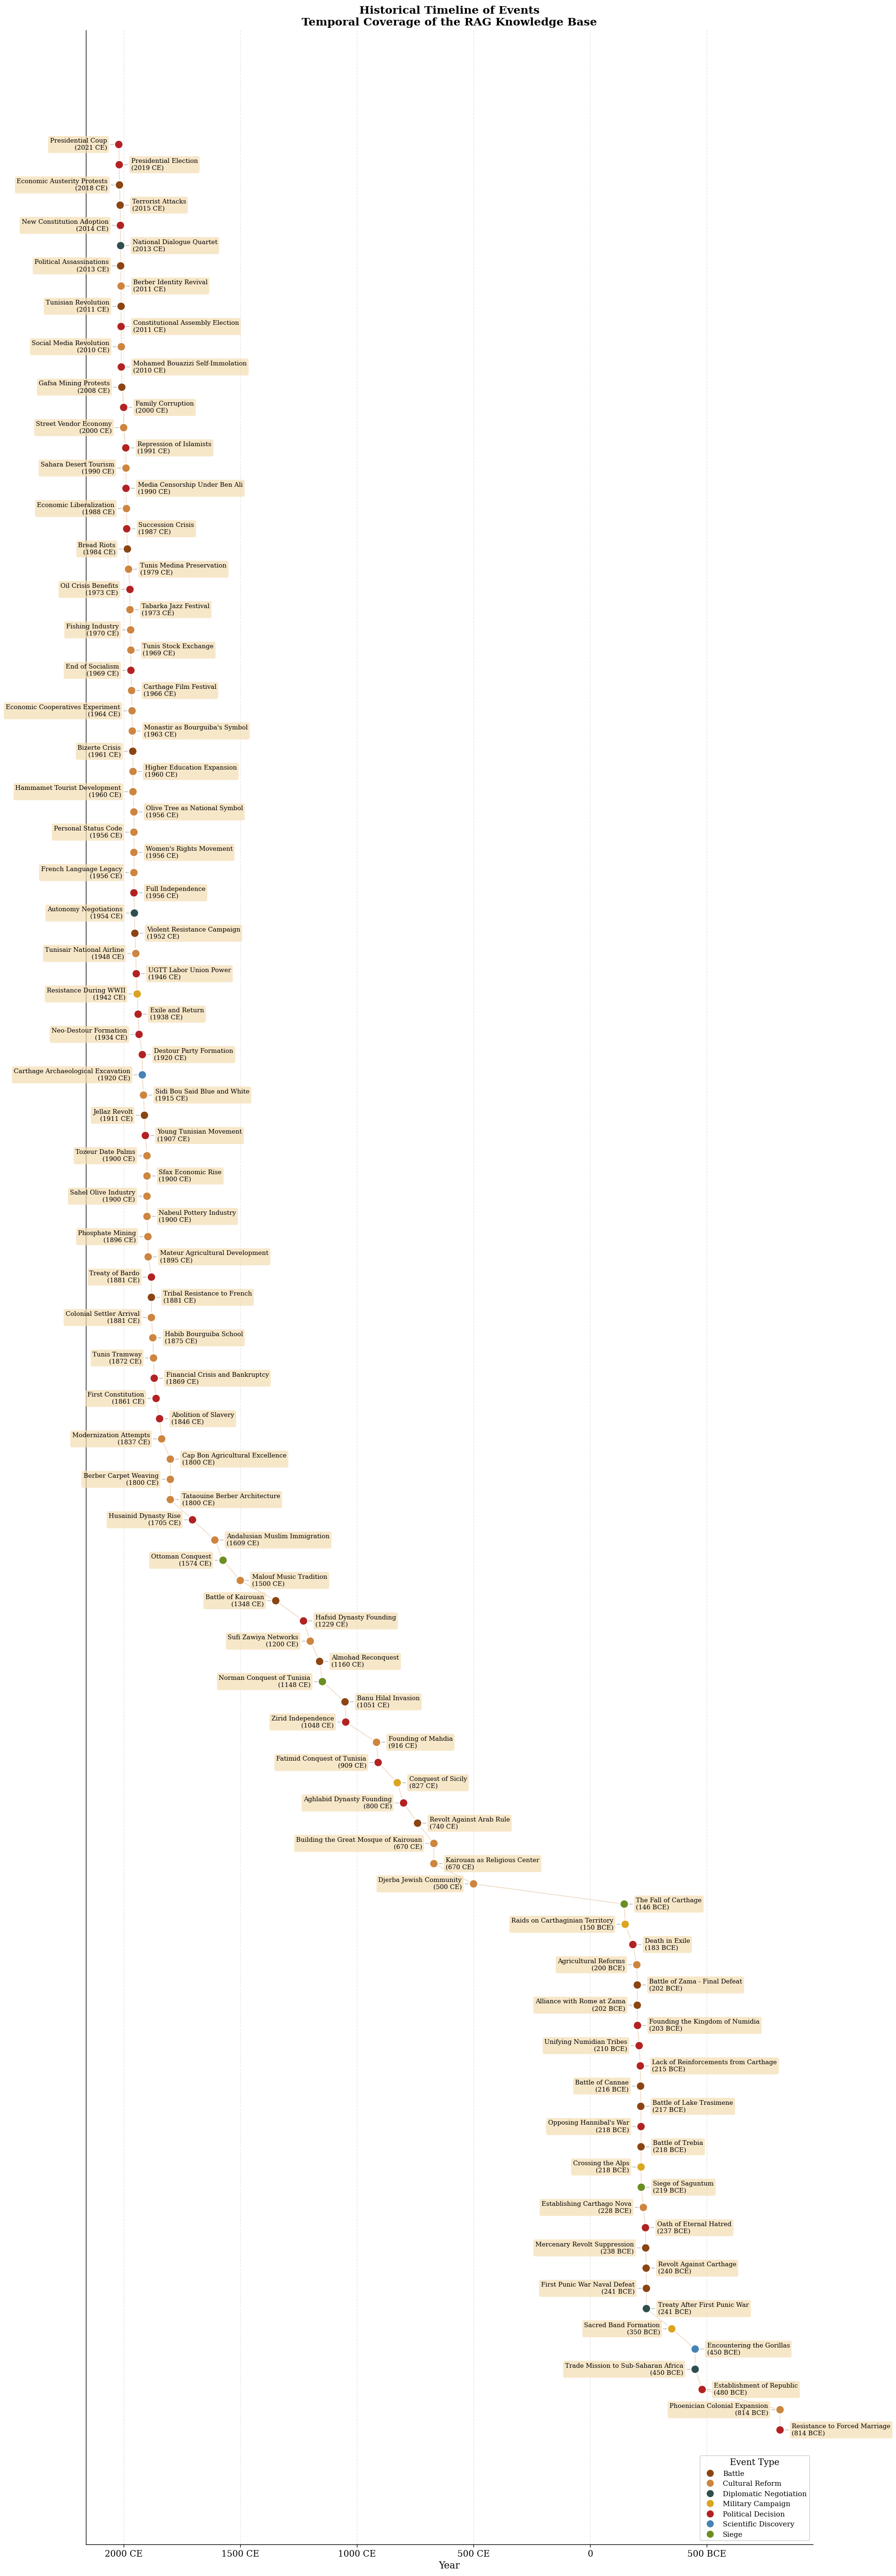

📊 Each point = one event. Gaps = periods where AI has no 'memory'
📊 Coverage: 814 BCE → 2021 CE


In [15]:
# --- 6.2 Historical Timeline ---

df_timeline = df[df['year'].notna()].copy()
df_timeline['year_numeric'] = df_timeline['year'].astype(float)
df_timeline = df_timeline.sort_values('year_numeric')

if len(df_timeline) > 0:
    fig, ax = plt.subplots(figsize=(16, max(6, len(df_timeline) * 0.4)))

    # Color by event type
    if 'type_of_event' in df_timeline.columns:
        event_types = df_timeline['type_of_event'].astype(str).unique()
        type_color_map = {t: COLORS['palette'][i % len(COLORS['palette'])]
                         for i, t in enumerate(sorted(event_types))}
        colors = [type_color_map[str(t)] for t in df_timeline['type_of_event']]
    else:
        colors = [COLORS['primary']] * len(df_timeline)

    y_positions = range(len(df_timeline))

    ax.scatter(df_timeline['year_numeric'], y_positions,
               c=colors, s=120, zorder=5, edgecolors='white', linewidth=1.5)
    ax.plot(df_timeline['year_numeric'], y_positions,
            color=COLORS['secondary'], alpha=0.3, linewidth=1, zorder=1)

    for i, (_, row) in enumerate(df_timeline.iterrows()):
        label = str(row.get('name_of_incident', ''))[:40]
        yr = row.get('year_display', '')
        offset = 15 if i % 2 == 0 else -15
        ha = 'left' if offset > 0 else 'right'

        ax.annotate(
            f"{label}\n({yr})",
            xy=(row['year_numeric'], i),
            xytext=(offset, 0), textcoords='offset points',
            fontsize=8, ha=ha, va='center',
            arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                     alpha=0.7, edgecolor='none')
        )

    # Legend
    if 'type_of_event' in df_timeline.columns:
        handles = [plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=type_color_map[t], markersize=10,
                   label=t) for t in sorted(event_types)]
        ax.legend(handles=handles, loc='lower right',
                 title='Event Type', fontsize=9)

    def format_year(x, pos):
        return f'{int(abs(x))} BCE' if x < 0 else (f'{int(x)} CE' if x > 0 else '0')

    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_year))
    ax.invert_xaxis()
    ax.set_yticks([])
    ax.set_xlabel('Year')
    ax.set_title('Historical Timeline of Events\n'
                 'Temporal Coverage of the RAG Knowledge Base',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('02_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("📊 Each point = one event. Gaps = periods where AI has no 'memory'")
    print(f"📊 Coverage: {df_timeline['year_display'].iloc[0]} → "
          f"{df_timeline['year_display'].iloc[-1]}")

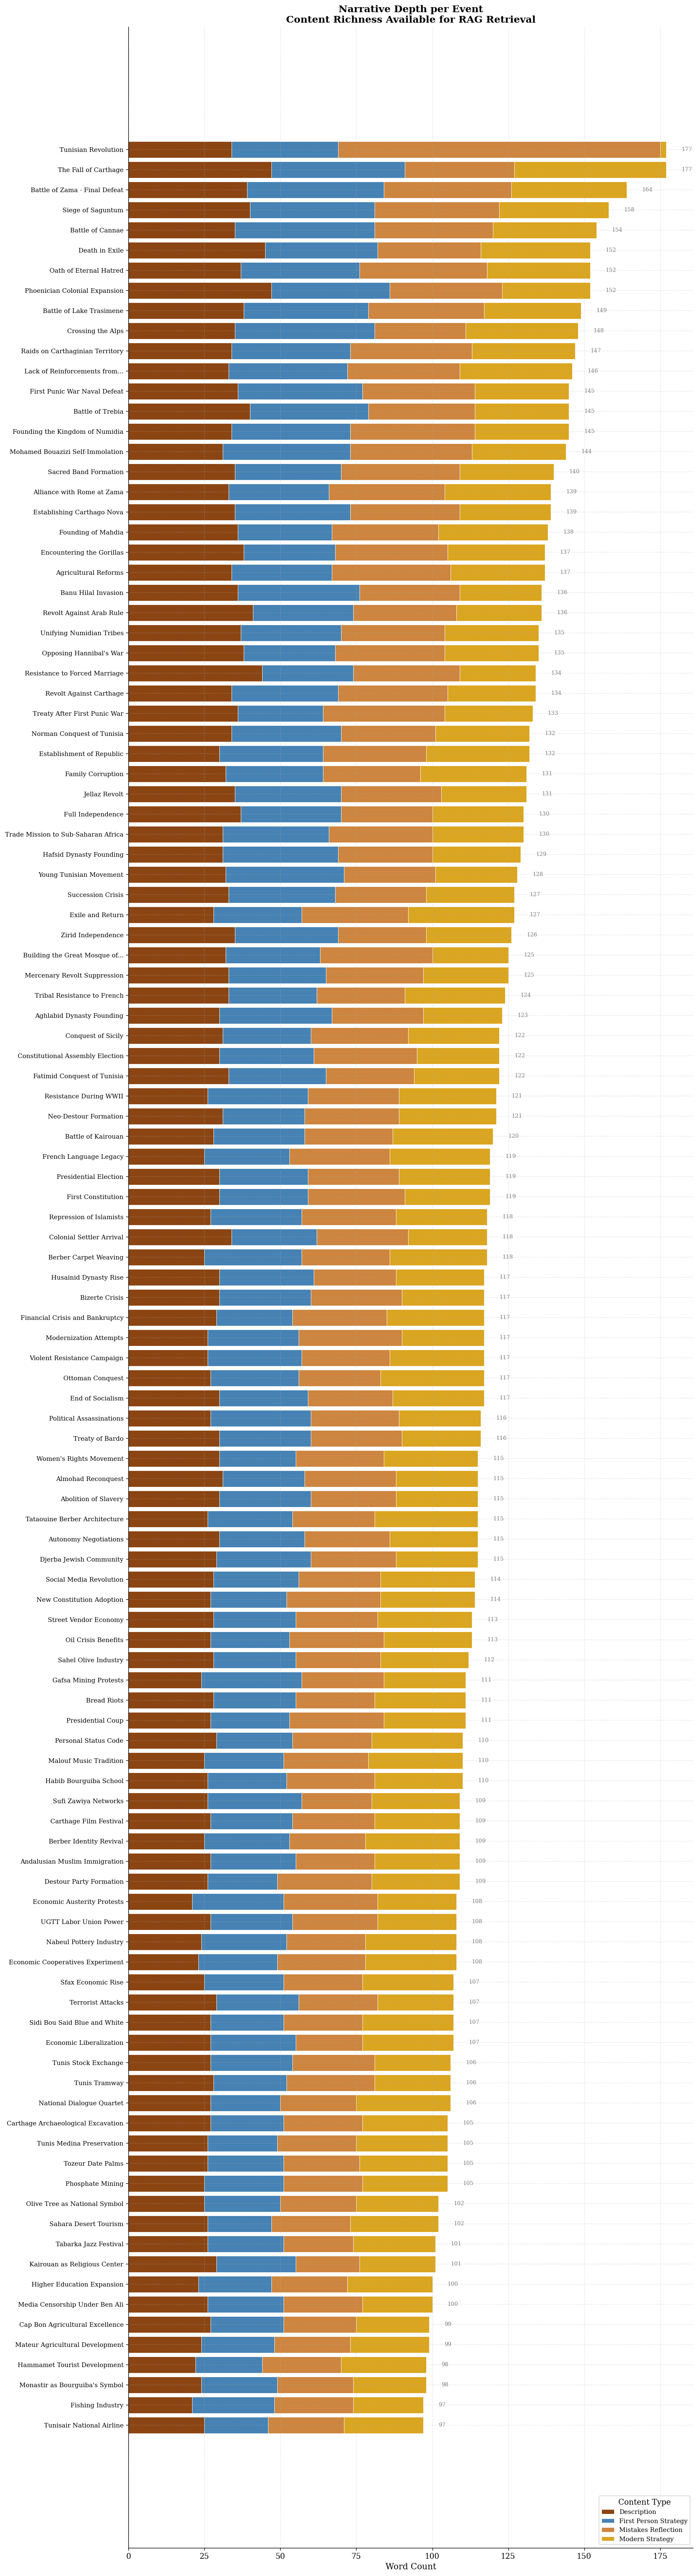

📊 Longer bars = richer events for AI character role-play
📊 'First Person Strategy' (blue) is most critical for character voice


In [16]:
# --- 6.3 Narrative Depth per Event ---

narrative_wc_cols = [c for c in df.columns
                     if c.endswith('_word_count')
                     and c not in ['rag_document_word_count', 'total_narrative_words']]

if narrative_wc_cols:
    df_plot = df.copy()
    if 'total_narrative_words' in df_plot.columns:
        df_plot = df_plot.sort_values('total_narrative_words', ascending=True)

    labels = df_plot['name_of_incident'].apply(
        lambda x: textwrap.shorten(str(x), width=35, placeholder='...')
    ).values

    fig, ax = plt.subplots(figsize=(14, max(6, len(df_plot) * 0.45)))

    bottoms = np.zeros(len(df_plot))
    bar_colors = [COLORS['primary'], COLORS['cool'],
                  COLORS['secondary'], COLORS['highlight']]
    clean_labels = [c.replace('_word_count', '').replace('_', ' ').title()
                    for c in narrative_wc_cols]

    for i, col in enumerate(narrative_wc_cols):
        values = df_plot[col].values
        ax.barh(range(len(df_plot)), values, left=bottoms,
                color=bar_colors[i % len(bar_colors)],
                edgecolor='white', linewidth=0.5,
                label=clean_labels[i])
        bottoms += values

    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Word Count')
    ax.set_title('Narrative Depth per Event\n'
                 'Content Richness Available for RAG Retrieval',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9, title='Content Type')

    for i, total in enumerate(bottoms):
        if total > 0:
            ax.text(total + 5, i, f'{int(total)}', va='center',
                   fontsize=8, color='gray')

    plt.tight_layout()
    plt.savefig('03_narrative_depth.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("📊 Longer bars = richer events for AI character role-play")
    print("📊 'First Person Strategy' (blue) is most critical for character voice")

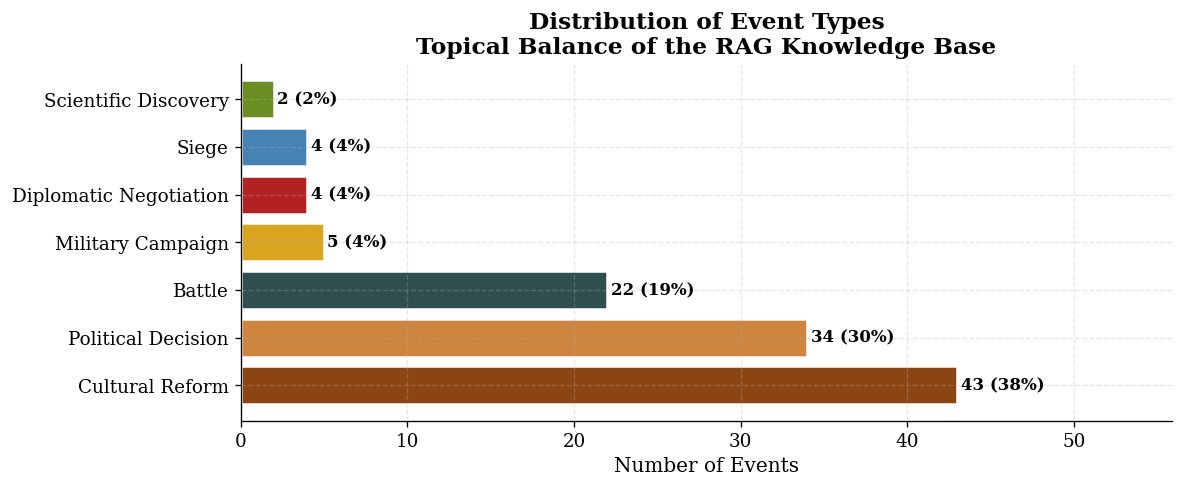

📊 Dominant: 'Cultural Reform' (38%)


In [17]:
# --- 6.4 Event Type Distribution ---

if 'type_of_event' in df.columns:
    type_counts = df['type_of_event'].value_counts()

    fig, ax = plt.subplots(figsize=(10, max(4, len(type_counts) * 0.6)))
    bars = ax.barh(range(len(type_counts)), type_counts.values,
                   color=COLORS['palette'][:len(type_counts)],
                   edgecolor='white', linewidth=1.5)
    ax.set_yticks(range(len(type_counts)))
    ax.set_yticklabels(type_counts.index, fontsize=11)
    ax.set_xlabel('Number of Events')
    ax.set_title('Distribution of Event Types\n'
                 'Topical Balance of the RAG Knowledge Base',
                 fontsize=14, fontweight='bold')

    for i, val in enumerate(type_counts.values):
        pct = val / len(df) * 100
        ax.text(val + 0.2, i, f'{val} ({pct:.0f}%)',
               va='center', fontsize=10, fontweight='bold')
    ax.set_xlim(0, type_counts.values.max() * 1.3)

    plt.tight_layout()
    plt.savefig('04_event_types.png', dpi=150, bbox_inches='tight')
    plt.show()

    dominant = type_counts.index[0]
    dominant_pct = type_counts.values[0] / len(df) * 100
    print(f"📊 Dominant: '{dominant}' ({dominant_pct:.0f}%)")
    if dominant_pct > 60:
        print("📊 ⚠ Consider adding diverse event types for balanced character depth")

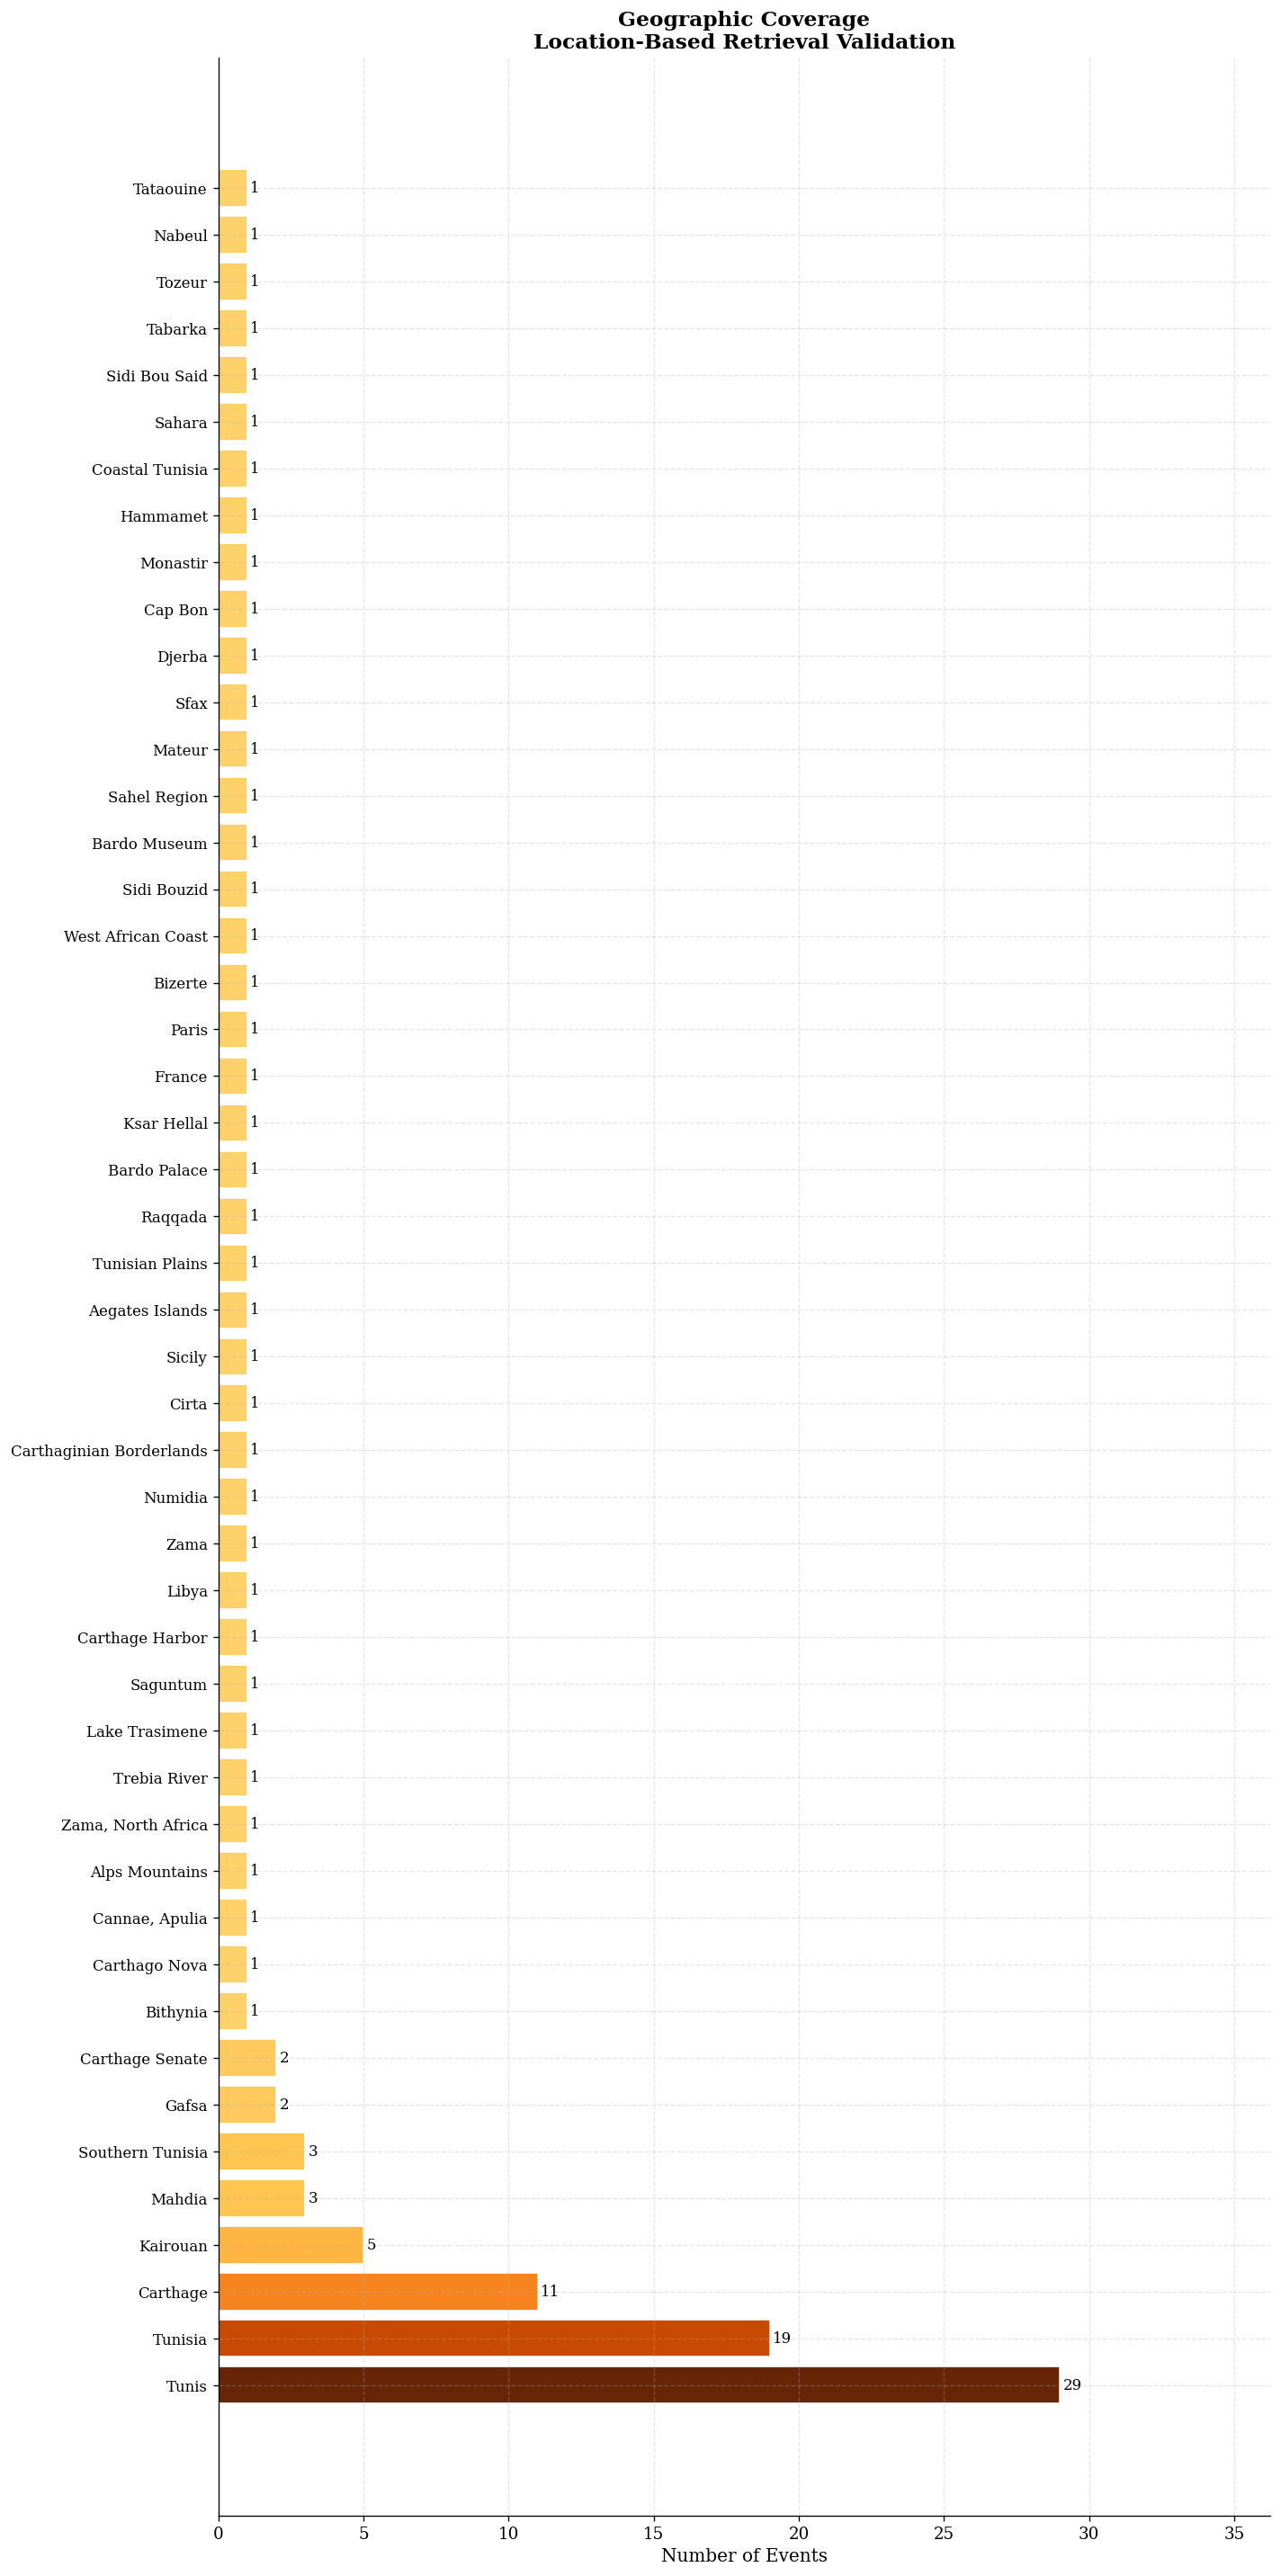

📊 40 locations have only 1 event — limited retrieval depth


In [18]:
# --- 6.5 Geographic Coverage ---

if 'place_name' in df.columns:
    place_counts = df['place_name'].value_counts()

    if len(place_counts) > 0:
        fig, ax = plt.subplots(figsize=(12, max(5, len(place_counts) * 0.5)))

        max_count = place_counts.values.max()
        colors = [plt.cm.YlOrBr(0.3 + 0.7 * v / max_count)
                  for v in place_counts.values]

        ax.barh(range(len(place_counts)), place_counts.values,
                color=colors, edgecolor='white', linewidth=1)
        ax.set_yticks(range(len(place_counts)))
        ax.set_yticklabels(place_counts.index, fontsize=10)
        ax.set_xlabel('Number of Events')
        ax.set_title('Geographic Coverage\n'
                     'Location-Based Retrieval Validation',
                     fontsize=14, fontweight='bold')

        for i, val in enumerate(place_counts.values):
            ax.text(val + 0.1, i, str(val), va='center', fontsize=10)
        ax.set_xlim(0, max_count * 1.25)

        plt.tight_layout()
        plt.savefig('05_geographic.png', dpi=150, bbox_inches='tight')
        plt.show()

        single = (place_counts == 1).sum()
        print(f"📊 {single} locations have only 1 event — limited retrieval depth")

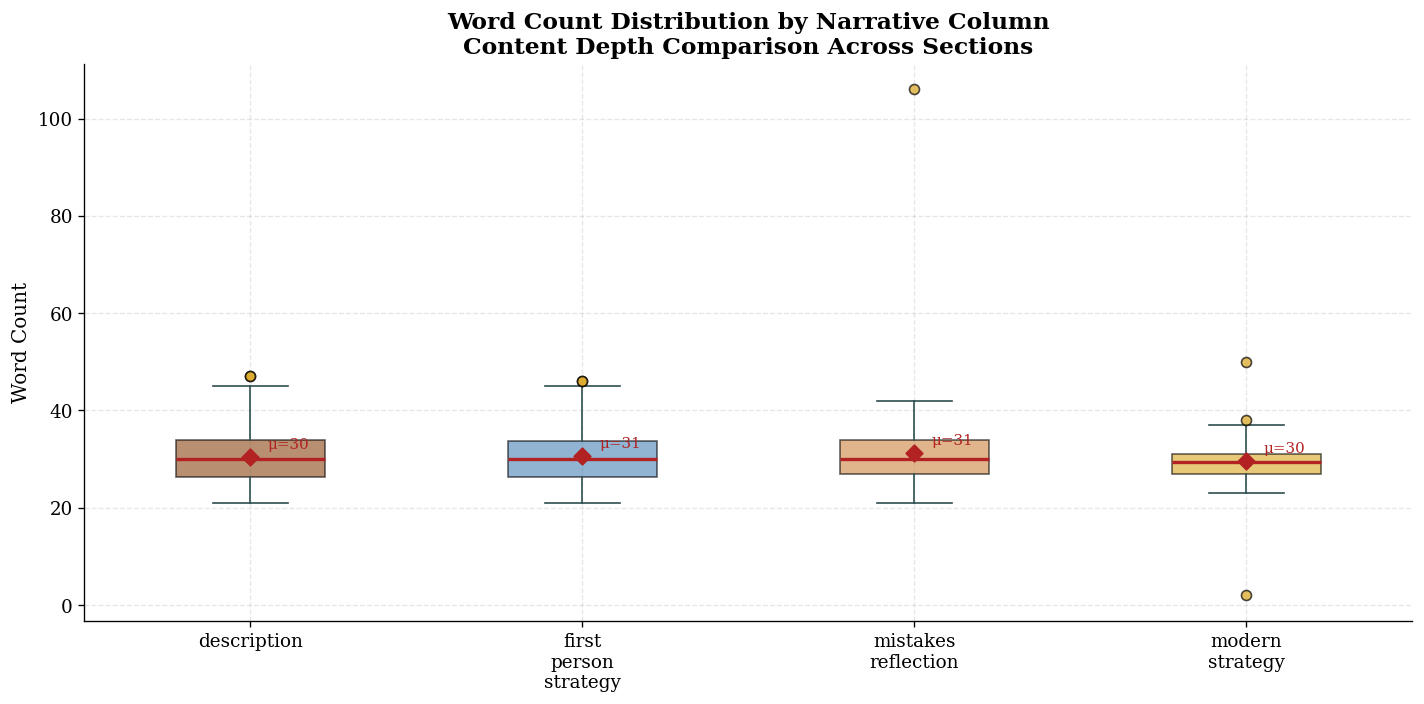

📊 'First Person Strategy' should ideally be the richest column
📊 Red diamond = mean, red line = median


In [19]:
# --- 6.6 Word Count Comparison (Box Plot) ---

wc_data = {}
for col in narrative_cols:
    wc_col = f'{col}_word_count'
    if wc_col in df.columns:
        valid = df[wc_col][df[wc_col] > 0].values
        if len(valid) > 0:
            wc_data[col.replace('_', '\n')] = valid

if wc_data:
    fig, ax = plt.subplots(figsize=(12, 6))

    bp = ax.boxplot(
        wc_data.values(), labels=wc_data.keys(), patch_artist=True,
        medianprops=dict(color=COLORS['danger'], linewidth=2),
        whiskerprops=dict(color=COLORS['accent']),
        capprops=dict(color=COLORS['accent']),
        flierprops=dict(marker='o', markerfacecolor=COLORS['highlight'],
                       markersize=6, alpha=0.7)
    )

    box_colors = [COLORS['primary'], COLORS['cool'],
                  COLORS['secondary'], COLORS['highlight']]
    for patch, color in zip(bp['boxes'], box_colors[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # Mean markers
    for i, (label, data) in enumerate(wc_data.items(), 1):
        mean_val = np.mean(data)
        ax.scatter(i, mean_val, marker='D', color=COLORS['danger'],
                  s=50, zorder=5)
        ax.annotate(f'μ={mean_val:.0f}', xy=(i, mean_val),
                   xytext=(10, 5), textcoords='offset points',
                   fontsize=9, color=COLORS['danger'])

    ax.set_ylabel('Word Count')
    ax.set_title('Word Count Distribution by Narrative Column\n'
                 'Content Depth Comparison Across Sections',
                 fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig('06_word_count_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("📊 'First Person Strategy' should ideally be the richest column")
    print("📊 Red diamond = mean, red line = median")

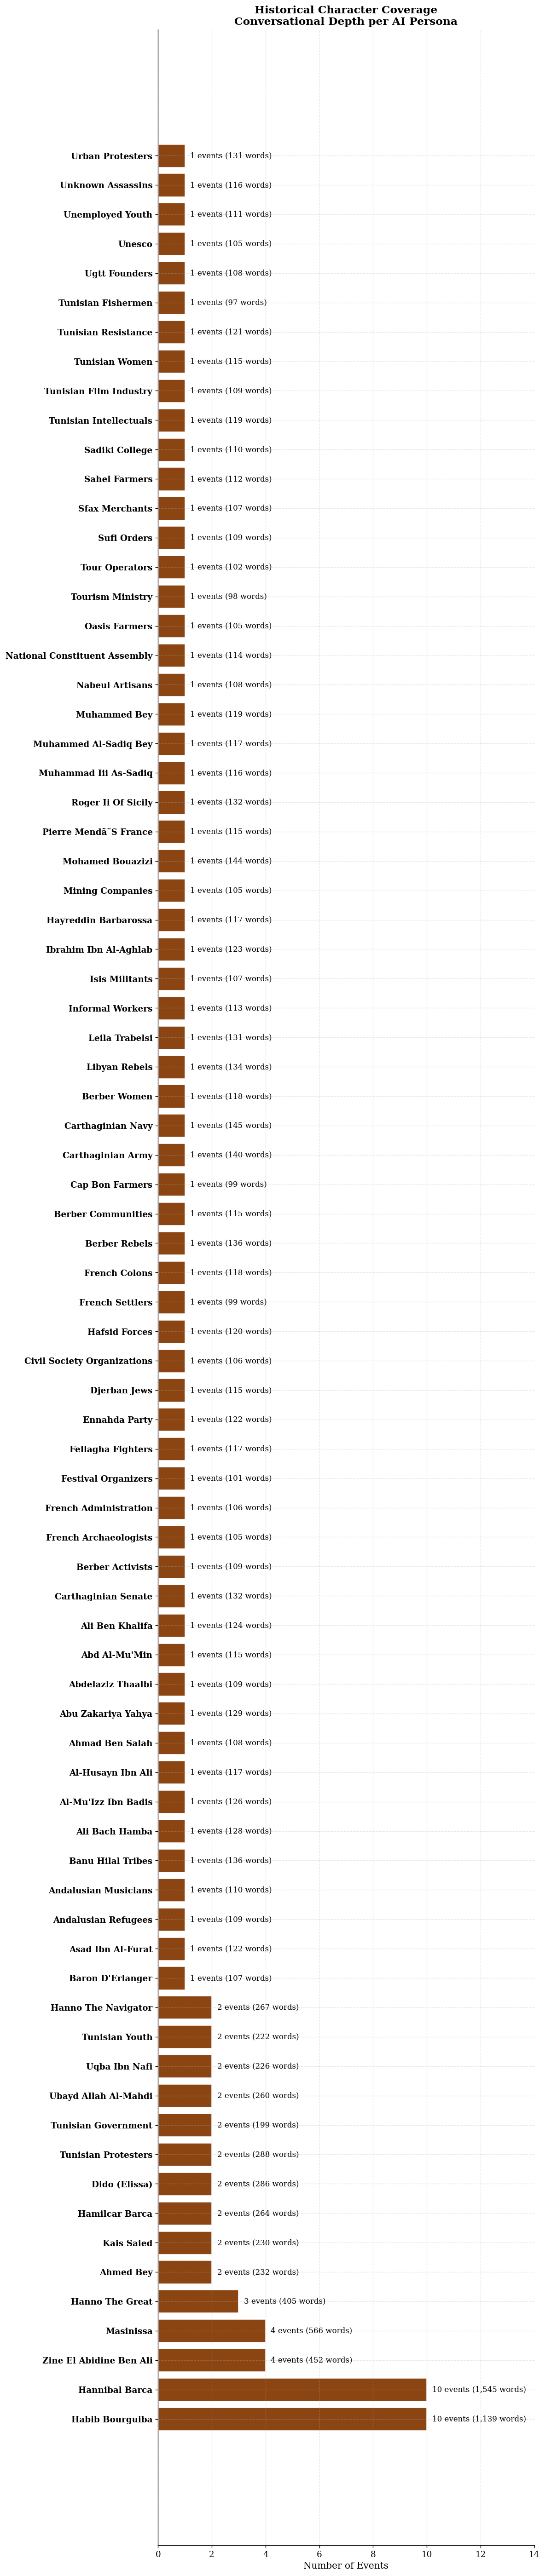

📊 More events + more words = richer AI persona
📊 Characters with few events will give thin, repetitive answers


In [20]:
# --- 6.7 Character Coverage ---

if 'historical_character' in df.columns:
    char_counts = df['historical_character'].value_counts()

    fig, ax = plt.subplots(figsize=(10, max(4, len(char_counts) * 0.6)))

    ax.barh(range(len(char_counts)), char_counts.values,
            color=COLORS['primary'], edgecolor='white', linewidth=1.5)
    ax.set_yticks(range(len(char_counts)))
    ax.set_yticklabels(char_counts.index, fontsize=11, fontweight='bold')
    ax.set_xlabel('Number of Events')
    ax.set_title('Historical Character Coverage\n'
                 'Conversational Depth per AI Persona',
                 fontsize=14, fontweight='bold')

    for i, val in enumerate(char_counts.values):
        char_name = char_counts.index[i]
        char_mask = df['historical_character'] == char_name
        if 'total_narrative_words' in df.columns:
            total_w = df.loc[char_mask, 'total_narrative_words'].sum()
            ax.text(val + 0.2, i, f'{val} events ({total_w:,} words)',
                   va='center', fontsize=10)
        else:
            ax.text(val + 0.2, i, str(val), va='center', fontsize=10)

    ax.set_xlim(0, char_counts.values.max() * 1.4)

    plt.tight_layout()
    plt.savefig('07_character_coverage.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("📊 More events + more words = richer AI persona")
    print("📊 Characters with few events will give thin, repetitive answers")

In [21]:
# ============================================================
# SECTION 7: FINAL EXPORT & QUALITY ASSERTIONS
# ============================================================

print(f"\n{'='*70}")
print(f"  FINAL EXPORT")
print(f"{'='*70}")

# --- Export 1: Full cleaned dataset ---
full_path = 'historical_events_cleaned_full.csv'
df.to_csv(full_path, index=False)
print(f"\n  1. Full dataset: {full_path}")
print(f"     Rows: {len(df)} | Columns: {len(df.columns)}")

# --- Export 2: RAG-ready subset ---
rag_cols = ['event_id', 'name_of_incident', 'year', 'year_display',
            'country', 'place_name', 'type_of_event', 'era',
            'historical_character', 'rag_document',
            'rag_document_word_count']
rag_cols_available = [c for c in rag_cols if c in df.columns]

if 'rag_ready' in df.columns:
    df_rag = df[df['rag_ready'] == 1][rag_cols_available].copy()
else:
    df_rag = df[rag_cols_available].copy()

rag_path = 'historical_events_rag_ready.csv'
df_rag.to_csv(rag_path, index=False)
print(f"\n  2. RAG-ready dataset: {rag_path}")
print(f"     Rows: {len(df_rag)} | Columns: {len(df_rag.columns)}")

# --- Quality Assertions ---
print(f"\n{'='*70}")
print(f"  QUALITY ASSERTIONS")
print(f"{'='*70}")

passed = 0
total = 0

# Assert 1: No unnamed columns
total += 1
unnamed_remaining = [c for c in df.columns if c.lower().startswith('unnamed')]
if not unnamed_remaining:
    print("  ✓ No 'Unnamed' columns remain")
    passed += 1
else:
    print(f"  ✗ Unnamed columns found: {unnamed_remaining}")

# Assert 2: No duplicate event_ids
total += 1
if 'event_id' in df.columns and df['event_id'].duplicated().sum() == 0:
    print("  ✓ No duplicate event_ids")
    passed += 1
else:
    print("  ✗ Duplicate event_ids found")

# Assert 3: No semantic nulls in metadata
total += 1
meta_cols = ['country', 'place_name', 'type_of_event', 'historical_character']
sem_nulls = sum(
    df[c].astype(str).apply(lambda x: x.strip().lower() in ['', 'n/a', 'na', 'null']).sum()
    for c in meta_cols if c in df.columns
)
if sem_nulls == 0:
    print("  ✓ No semantic nulls in metadata")
    passed += 1
else:
    print(f"  ✗ {sem_nulls} semantic nulls remain")

# Assert 4: All RAG documents have content
total += 1
if 'rag_document' in df.columns:
    empty_docs = (df['rag_document'].str.strip() == '').sum()
    if empty_docs == 0:
        print("  ✓ All RAG documents have content")
        passed += 1
    else:
        print(f"  ✗ {empty_docs} empty RAG documents")

# Assert 5: Year is numeric
total += 1
if 'year' in df.columns:
    non_null = df['year'].dropna()
    if pd.to_numeric(non_null, errors='coerce').notna().all():
        print("  ✓ All year values are numeric")
        passed += 1
    else:
        print("  ✗ Non-numeric year values found")

# Assert 6: Proper entity capitalization
total += 1
if 'historical_character' in df.columns:
    chars = df['historical_character'].dropna().unique()
    bad_caps = [c for c in chars if c != c.title() and c != 'Unknown']
    if not bad_caps:
        print("  ✓ All character names properly capitalized")
        passed += 1
    else:
        print(f"  ✗ Bad capitalization: {bad_caps}")

print(f"\n  Results: {passed}/{total} assertions passed")
if passed == total:
    print("  🎉 Dataset is clean and ready for RAG pipeline!")

# --- Pipeline Summary ---
print(f"\n{'='*70}")
print(f"  PIPELINE SUMMARY")
print(f"{'='*70}")
print(f"  Original rows:      {len(df_raw)}")
print(f"  Cleaned rows:       {len(df)}")
print(f"  RAG-ready rows:     {len(df_rag)}")
print(f"  Features created:   {len(df.columns) - len(EXPECTED_COLUMNS)}")
print(f"  Unnamed removed:    {len([c for c in df_raw.columns if c.lower().startswith('unnamed')])}")

print(f"\n  Final columns:")
for i, col in enumerate(df.columns, 1):
    origin = "original" if col in EXPECTED_COLUMNS else "engineered"
    print(f"    {i:2d}. {col:40s} [{origin}]")

# --- Sample RAG Document ---
print(f"\n{'='*70}")
print(f"  SAMPLE RAG DOCUMENT")
print(f"{'='*70}")
sample = df_rag['rag_document'].iloc[0]
print(f"\n{sample[:600]}")
if len(sample) > 600:
    print(f"\n  [...total {len(sample.split())} words]")


  FINAL EXPORT

  1. Full dataset: historical_events_cleaned_full.csv
     Rows: 114 | Columns: 34

  2. RAG-ready dataset: historical_events_rag_ready.csv
     Rows: 114 | Columns: 11

  QUALITY ASSERTIONS
  ✓ No 'Unnamed' columns remain
  ✓ No duplicate event_ids
  ✓ No semantic nulls in metadata
  ✓ All RAG documents have content
  ✓ All year values are numeric
  ✓ All character names properly capitalized

  Results: 6/6 assertions passed
  🎉 Dataset is clean and ready for RAG pipeline!

  PIPELINE SUMMARY
  Original rows:      114
  Cleaned rows:       114
  RAG-ready rows:     114
  Features created:   23
  Unnamed removed:    0

  Final columns:
     1. event_id                                 [original]
     2. name_of_incident                         [original]
     3. year                                     [original]
     4. country                                  [original]
     5. place_name                               [original]
     6. type_of_event                  